# 量子增强神经网络实现

本笔记本实现了论文《Quantum-enhanced neural networks for quantum many-body simulations》中描述的量子神经网络架构。

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import Image

# 设置随机种子以确保结果可重现
np.random.seed(42)

## 1. 量子神经网络架构概述

根据论文，量子神经网络（QNN）由以下部分组成：
1. **编码层**：将经典数据编码到量子态
2. **变分层**：参数化量子门组成的层，用于学习
3. **测量层**：测量量子态以获得经典输出

我们将实现一个硬件高效的量子神经网络（Hardware-Efficient Quantum Neural Network），这种架构适合在当前的量子设备上实现。

## 2. 定义量子设备

In [2]:
# 定义量子设备
n_qubits = 4  # 量子比特数量
dev = qml.device("default.qubit", wires=n_qubits)

## 3. 实现量子神经网络

我们将实现一个硬件高效的量子神经网络，包含以下组件：
1. **数据编码**：使用旋转门将输入数据编码到量子态
2. **变分层**：交替使用单量子比特旋转门和纠缠门
3. **测量**：测量每个量子比特的期望值

In [3]:
def data_encoding(x):
    """将输入数据编码到量子态
    
    Args:
        x (array): 输入数据
        wires (list): 量子比特索引列表
    """
    for index,i in enumerate(x):
        if i == 1:
            qml.X(wires=index)
    qml.Barrier(wires=range(len(x)))
def variational_layer(params, wires, entanglement='linear'):
    """变分层，包含单量子比特旋转门和纠缠门
    
    Args:
        params (array): 可训练参数
        wires (list): 量子比特索引列表
        entanglement (str): 纠缠策略，'linear'或'full'
    """
    n_wires = len(wires)
    
    # 单量子比特旋转门
    for i, wire in enumerate(wires):
        qml.RX(params[2*i], wires=wire)
        qml.RZ(params[2*i+1], wires=wire)
    
    # 纠缠门
    if entanglement == 'linear':
        # 线性纠缠：相邻量子比特之间纠缠
        for i in range(n_wires - 1):
            qml.CNOT(wires=[wires[i], wires[i+1]])
    elif entanglement == 'full':
        # 全纠缠：所有量子比特之间两两纠缠
        for i in range(n_wires):
            for j in range(i+1, n_wires):
                qml.CNOT(wires=[wires[i], wires[j]])
    qml.Barrier(wires=range(n_wires))

def quantum_neural_network(x, params, n_layers=2, entanglement='linear'):
    """量子神经网络
    
    Args:
        x (array): 输入数据
        params (array): 可训练参数
        n_layers (int): 变分层数量
        entanglement (str): 纠缠策略
    """
    wires = range(n_qubits)
    
    # 数据编码
    data_encoding(x)
    
    # 变分层
    for layer in range(n_layers):
        variational_layer(params[layer], wires, entanglement)
    
    # 测量
    return [qml.expval(qml.PauliZ(i)) for i in wires]

## 4. 创建量子节点

In [4]:
# 创建量子节点
@qml.qnode(dev)
def qnn_circuit(x, params, n_layers=2, entanglement='linear'):
    return quantum_neural_network(x, params, n_layers, entanglement)

# 定义输出函数，将量子测量结果转换为标量输出
def output_function(expvals, weights=None):
    """将量子测量结果转换为标量输出
    
    Args:
        expvals (list): 量子测量结果列表
        weights (array): 输出权重
    """
    if weights is None:
        weights = np.ones(len(expvals)) / len(expvals)
    return np.dot(weights, expvals)

# 完整的QNN函数
def qnn(x, params, n_layers=2, entanglement='linear', output_weights=None):
    """完整的量子神经网络函数
    
    Args:
        x (array): 输入数据
        params (array): 可训练参数
        n_layers (int): 变分层数量
        entanglement (str): 纠缠策略
        output_weights (array): 输出权重
    """
    expvals = qnn_circuit(x, params, n_layers, entanglement)
    return output_function(expvals, output_weights)

## 5. 初始化参数

In [5]:
# 初始化参数
def initialize_parameters(n_layers, n_qubits):
    """初始化量子神经网络参数
    
    Args:
        n_layers (int): 变分层数量
        n_qubits (int): 量子比特数量
        
    Returns:
        array: 初始化的参数
    """
    # 每个变分层有3*n_qubits个参数（每个量子比特有RX, RY, RZ三个旋转门）
    params_shape = (n_layers, 2 * n_qubits)
    return np.random.uniform(0, 2*np.pi, size=params_shape)

# 初始化参数
n_layers = 2
params = initialize_parameters(n_layers, n_qubits)
output_weights = np.random.uniform(0, 1, size=n_qubits)

print(f"参数形状: {params.shape}")
print(f"输出权重: {output_weights}")

参数形状: (2, 8)
输出权重: [0.00706631 0.02306243 0.52477466 0.39986097]


## 6. 可视化量子电路

量子神经网络电路结构:


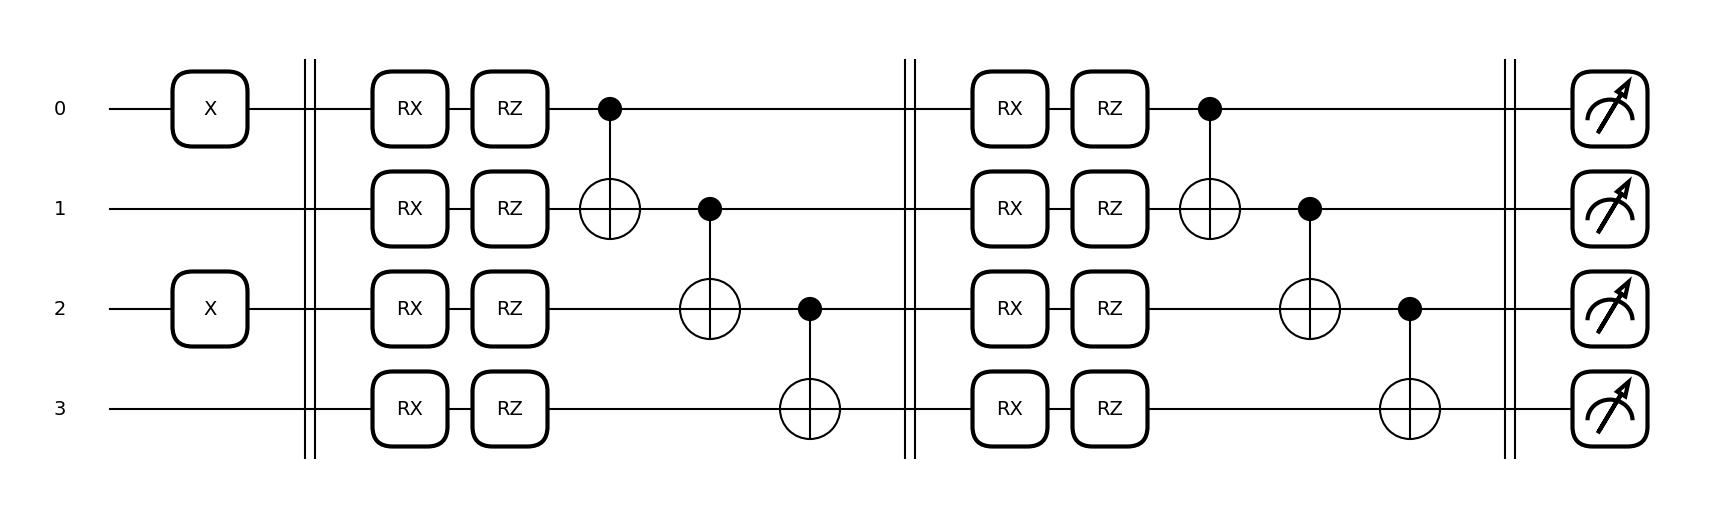

In [6]:
# 创建测试输入
test_input = [1,0,1,0]

# 绘制量子电路
print("量子神经网络电路结构:")
fig, ax = qml.draw_mpl(qnn_circuit)(test_input, params, n_layers, 'linear')
plt.show()

In [7]:
qnn_circuit(test_input,params)

[tensor(0.26316477, requires_grad=True),
 tensor(-0.1941959, requires_grad=True),
 tensor(-0.06452205, requires_grad=True),
 tensor(-0.14248526, requires_grad=True)]

## 7. 测试量子神经网络

In [8]:
# 测试量子神经网络
test_input = np.array([0.1, 0.5, 0.3, 0.8])
output = qnn(test_input, params, n_layers, 'linear', output_weights)

print(f"输入: {test_input}")
print(f"输出: {output}")

# 测试多个输入
print("\n测试多个输入:")
for i in range(5):
    x = np.random.uniform(0, np.pi, size=n_qubits)
    y = qnn(x, params, n_layers, 'linear', output_weights)
    print(f"输入 {i+1}: {x}, 输出: {y:.4f}")

输入: [0.1 0.5 0.3 0.8]
输出: -0.0829150446150832

测试多个输入:
输入 1: [0.1466045  3.05914318 0.73127273 0.28464851], 输出: -0.0829
输入 2: [1.94271694 1.20153978 3.08891093 1.46637888], 输出: -0.0829
输入 3: [2.70158246 2.13724917 1.41528514 0.0416731 ], 输出: -0.0829
输入 4: [2.96001411 1.76962213 1.21082165 0.05015946], 输出: -0.0829
输入 5: [0.72537435 0.75720383 2.14653565 1.91636102], 输出: -0.0829


## 8. 量子神经网络的训练（示例）

下面我们展示如何使用梯度下降法训练量子神经网络来解决一个简单的回归问题。

In [9]:
# 定义目标函数
def target_function(x):
    """目标函数：简单的非线性函数
    
    Args:
        x (array): 输入数据
        
    Returns:
        float: 目标值
    """
    return np.sin(x[0]) * np.cos(x[1]) + 0.5 * x[2]

# 定义损失函数（均方误差）
def loss_function(params, output_weights, X, Y):
    """计算损失函数
    
    Args:
        params (array): 量子神经网络参数
        output_weights (array): 输出权重
        X (list): 输入数据列表
        Y (list): 目标值列表
        
    Returns:
        float: 损失值
    """
    loss = 0
    for x, y in zip(X, Y):
        prediction = qnn(x, params, n_layers, 'linear', output_weights)
        loss += (prediction - y) ** 2
    return loss / len(X)

# 生成训练数据
n_samples = 20
X_train = []
Y_train = []

for _ in range(n_samples):
    x = np.random.uniform(0, np.pi, size=n_qubits)
    y = target_function(x)
    X_train.append(x)
    Y_train.append(y)

print(f"生成了 {n_samples} 个训练样本")
print(f"第一个样本: 输入 {X_train[0]}, 目标 {Y_train[0]:.4f}")

生成了 20 个训练样本
第一个样本: 输入 [2.61755901 0.54464112 1.22855313 0.57251155], 目标 1.0423


## 10. 总结

在本笔记本中，我们实现了论文《Quantum-enhanced neural networks for quantum many-body simulations》中描述的量子神经网络架构。主要内容包括：

1. **量子神经网络架构**：实现了硬件高效的量子神经网络，包含数据编码层、变分层和测量层。
2. **纠缠策略**：实现了线性纠缠和全纠缠两种策略，并比较了它们的差异。
3. **训练和测试**：展示了如何使用梯度下降法训练量子神经网络来解决回归问题。

这个实现可以作为量子增强神经网络的基础，用于量子多体系统的模拟。通过调整网络结构、纠缠策略和训练方法，可以进一步优化性能以适应不同的应用场景。